In [5]:
import pandas as pd

df_raw = pd.read_csv('../data/raw/train.csv')

df_raw.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

## 1. Copy the original dataframe

In [7]:
df = df_raw.copy()

## 2. Delete the unused cells

In [8]:
df.drop('id', axis=1, inplace=True)

df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 3. Column Naming & Data Standardization

In [16]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

cat_cols = df.select_dtypes(include=["str"]).columns

for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].astype(str).str.lower()

df.head()

,soil_type,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,temperature_c,humidity,rainfall_mm,sunlight_hours,wind_speed_kmh,crop_type,crop_growth_stage,season,irrigation_type,water_source,field_area_hectare,mulching_used,previous_irrigation_mm,region,irrigation_need
0,loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,sugarcane,sowing,zaid,drip,rainwater,0.82,no,112.16,east,low
1,clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,wheat,vegetative,kharif,rainfed,river,5.27,yes,47.16,south,low
2,clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,rice,vegetative,kharif,sprinkler,reservoir,8.24,yes,110.38,north,low
3,sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,wheat,flowering,kharif,canal,river,8.32,yes,53.85,south,medium
4,clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,wheat,sowing,rabi,canal,river,7.37,no,93.19,south,low


## 4. Look for duplicated data

In [18]:
print(f'Duplicated data: ', df.duplicated().sum())

Duplicated data:  0


## 5. Check for the unique value in categorical columns

This can be useful when we want to work with ```get_dummies()``` method later.

In [17]:
unique_soil_type = df['soil_type'].nunique()
unique_crop_type = df['crop_type'].nunique()
unique_crop_growth = df['crop_growth_stage'].nunique()
unique_season = df['season'].nunique()
unique_irrigation_type = df['irrigation_type'].nunique()
unique_water_source = df['water_source'].nunique()
unique_region = df['region'].nunique()
unique_irrigation_need = df['irrigation_need'].nunique()

print(f'Unique soil type: {unique_soil_type}')
print(f'Unique crop type: {unique_crop_type}')
print(f'Unique crop growth stage: {unique_crop_growth}')
print(f'Unique season: {unique_season}')
print(f'Unique irrigation type: {unique_irrigation_type}')
print(f'Unique water source: {unique_water_source}')
print(f'Unique region: {unique_region}')
print(f'Unique irrigation need: {unique_irrigation_need}')

Unique soil type: 4
Unique crop type: 6
Unique crop growth stage: 4
Unique season: 3
Unique irrigation type: 4
Unique water source: 4
Unique region: 5
Unique irrigation need: 3


We can see all unique values on each column. Let's break it down.

We can use ordinal for:
- crop growth stage
- irrigation need

**since the value of those columns act like a stage**

------------------------------------------------------

We can use binary for:
- mulching used

**since there only two values: *yes / no***

------------------------------------------------------

We can use hot encoding for all other categorical columns

In [19]:
growth_stage_map = {'sowing': 0, 'vegetative': 1, 'flowering': 2, 'harvest': 3}
irrigation_map = {'low': 0, 'medium': 1, 'high': 2}
mulching_map = {'no': 0, 'yes': 1}

hot_enc_cols = ['soil_type', 'crop_type', 'season', 'irrigation_type', 'water_source', 'region']

# Ordinal
df['crop_growth_stage'] = df['crop_growth_stage'].map(growth_stage_map)
df['irrigation_need'] = df['irrigation_need'].map(irrigation_map)

# Binary
df['mulching_used'] = df['mulching_used'].map(mulching_map)

# Hot encoding
df = pd.get_dummies(df, columns=hot_enc_cols, drop_first=True)

df.head()

,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,temperature_c,humidity,rainfall_mm,sunlight_hours,wind_speed_kmh,crop_growth_stage,...,irrigation_type_drip,irrigation_type_rainfed,irrigation_type_sprinkler,water_source_rainwater,water_source_reservoir,water_source_river,region_east,region_north,region_south,region_west
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0,...,True,False,False,True,False,False,True,False,False,False
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,1,...,False,True,False,False,False,True,False,False,True,False
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,1,...,False,False,True,False,True,False,False,True,False,False
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,2,...,False,False,False,False,False,True,False,False,True,False
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,0,...,False,False,False,False,False,True,False,False,True,False


## 6. Check for null values

In [21]:
print(f'Null values: ', df.isna().sum())

Null values:  soil_ph                      0
soil_moisture                0
organic_carbon               0
electrical_conductivity      0
temperature_c                0
humidity                     0
rainfall_mm                  0
sunlight_hours               0
wind_speed_kmh               0
crop_growth_stage            0
field_area_hectare           0
mulching_used                0
previous_irrigation_mm       0
irrigation_need              0
soil_type_loamy              0
soil_type_sandy              0
soil_type_silt               0
crop_type_maize              0
crop_type_potato             0
crop_type_rice               0
crop_type_sugarcane          0
crop_type_wheat              0
season_rabi                  0
season_zaid                  0
irrigation_type_drip         0
irrigation_type_rainfed      0
irrigation_type_sprinkler    0
water_source_rainwater       0
water_source_reservoir       0
water_source_river           0
region_east                  0
region_north             

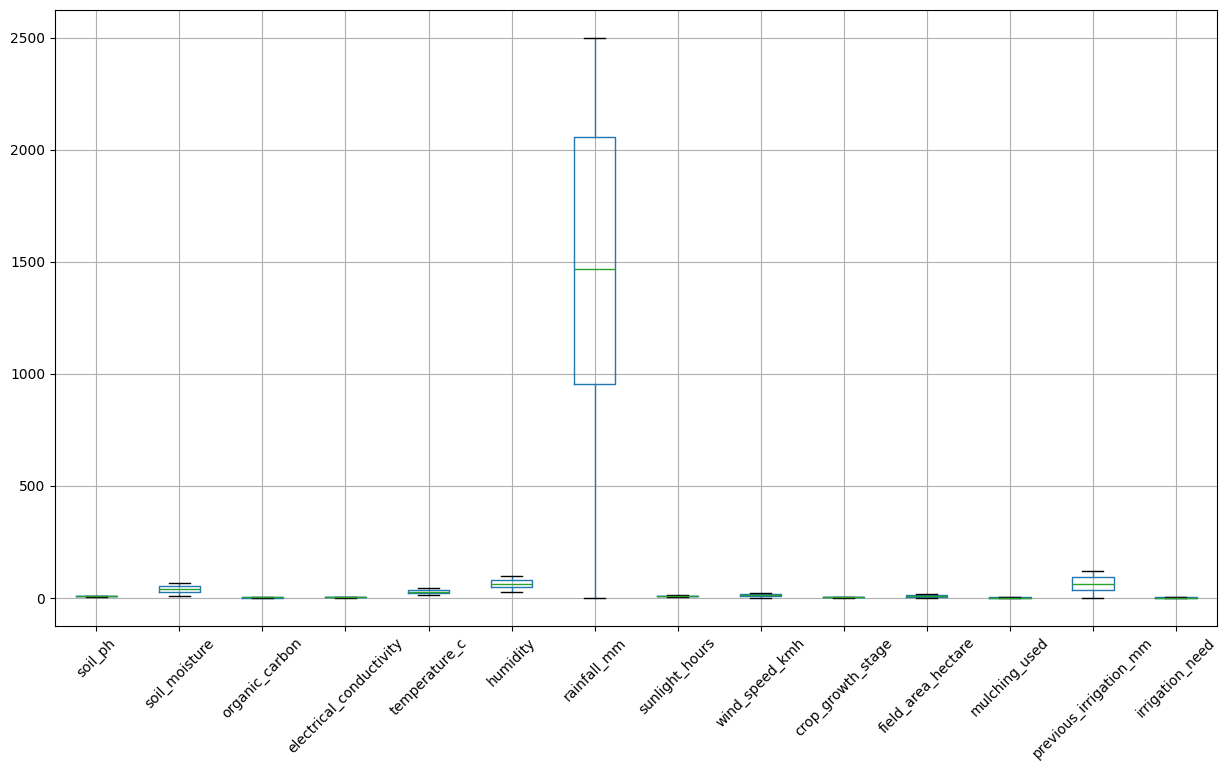

In [22]:
import matplotlib.pyplot as plt

# Plot all numerical columns to see the distribution
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols].boxplot(figsize=(15, 8))
plt.xticks(rotation=45)
plt.show()